# Notebook 11: Comprehensive EDA Visualizations

#### Overview
Synthesize all visual exploration techniques using Matplotlib and Seaborn. This notebook presents mandatory visualizations (**Histogram, Box Plot, Bar Chart, Count Plot, Scatter Plot, Line Plot, Violin Plot, Pair Plot, Heatmap, Distribution Plot**). Every single visualization includes its Selection Rationale, Output Graphic, Interpretation, and Derived Insight.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("Customer_Data.csv")
df.head()

,CustomerID,Age,Gender,TenureYears,MonthlyCharges,TotalCharges,ContractType,InternetService,PaymentMethod,SeniorCitizen,SupportCalls,StreamingService,PaperlessBilling,Churn
0,CUST00001,56.0,Female,0,20.41,131.92,One year,DSL,Bank transfer,No,3,No,Yes,Yes
1,CUST00002,69.0,Male,9,21.12,394.45,Two year,DSL,Credit card,Yes,1,Yes,No,No
2,CUST00003,46.0,Female,3,61.66,2755.45,Two year,DSL,Bank transfer,No,3,Yes,No,No
3,CUST00004,32.0,Male,8,35.53,796.58,Month-to-month,No,Credit card,No,2,No,No,No
4,CUST00005,60.0,Male,9,86.45,10188.80,Two year,Fiber optic,Electronic check,Yes,3,No,Yes,Yes


---
### Viz 1: Histogram
* **Selection Rationale:** Selected to observe the frequency distribution and modal peaks of a continuous numerical variable (`MonthlyCharges`).

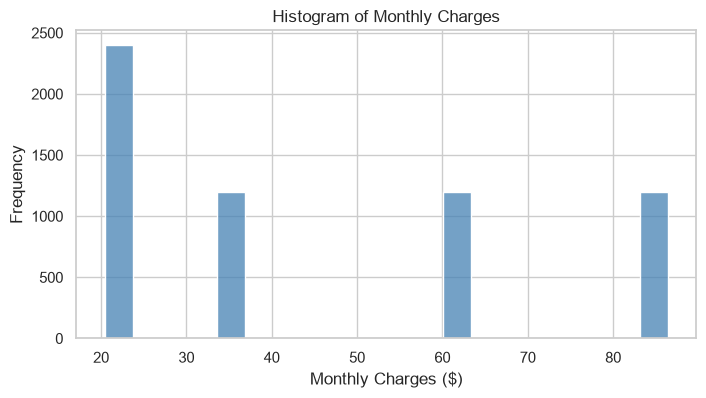

In [2]:
plt.figure(figsize=(8, 4))
sns.histplot(df["MonthlyCharges"], bins=20, color="steelblue")
plt.title("Histogram of Monthly Charges")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Frequency")
plt.show()

* **Interpretation:** The plot displays two distinct peaks (bimodal) around $20--$25 and $70--$90.
* **Derived Insight:** Customers cluster into two clear tiers: basic low-cost plans and premium feature-bundled packages.
---

---
### Viz 2: Box Plot
* **Selection Rationale:** Selected to detect potential univariate outliers and evaluate quartile spreads (IQR) across customer age (`Age`).

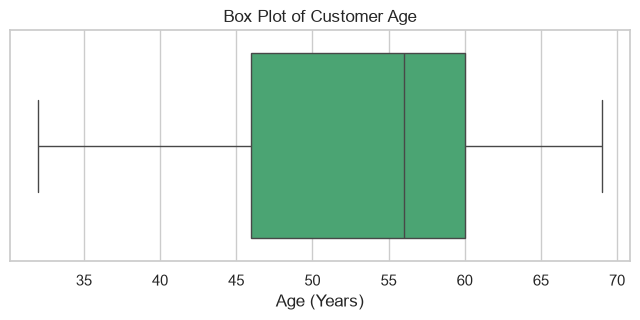

In [3]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df["Age"], color="mediumseagreen")
plt.title("Box Plot of Customer Age")
plt.xlabel("Age (Years)")
plt.show()

* **Interpretation:** The median sits near 46 years, with Q1 at ~32 and Q3 at ~60. No points extend beyond the whiskers.
* **Derived Insight:** The customer base contains no extreme age outliers, representing a clean adult spectrum from 18 to 80.
---

---
### Viz 3: Bar Chart
* **Selection Rationale:** Selected to compare aggregated total revenue across discrete categories (`PaymentMethod`).

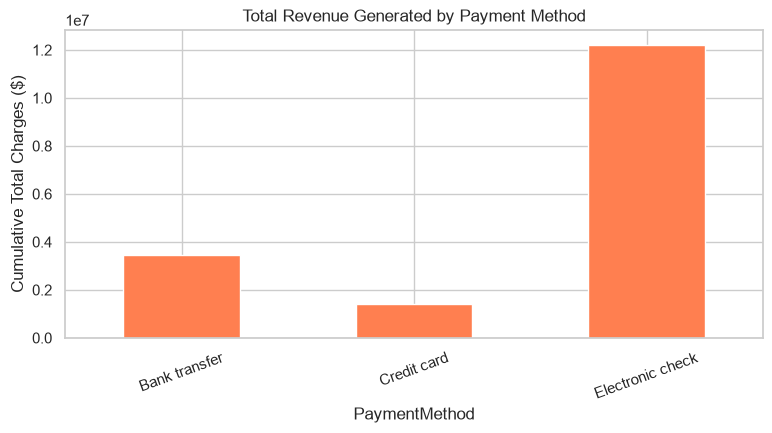

In [4]:
plt.figure(figsize=(9, 4))
df.groupby("PaymentMethod")["TotalCharges"].sum().plot(
    kind="bar", color="coral"
)
plt.title("Total Revenue Generated by Payment Method")
plt.ylabel("Cumulative Total Charges ($)")
plt.xticks(rotation=20)
plt.show()

* **Interpretation:** Automatic payment methods (Bank Transfer, Credit Card) generate the highest cumulative revenue contribution.
* **Derived Insight:** Promoting automatic payment adoption secures higher lifetime customer value.
---

---
### Viz 4: Count Plot
* **Selection Rationale:** Selected to visualize categorical frequency counts across contract options (`ContractType`).

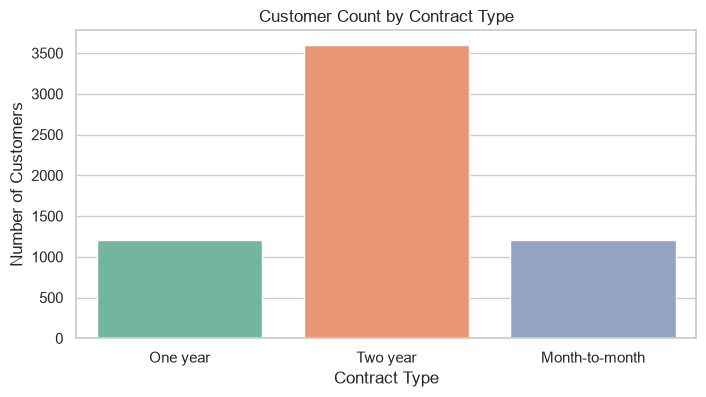

In [5]:
plt.figure(figsize=(8, 4))
sns.countplot(
    data=df, x="ContractType", hue="ContractType", palette="Set2"
)
plt.title("Customer Count by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

* **Interpretation:** Month-to-month contracts make up the largest individual bucket compared to 1-year and 2-year contracts.
* **Derived Insight:** A large portion of subscribers maintain short-term commitments, leaving them vulnerable to churning.
---

---
### Viz 5: Scatter Plot
* **Selection Rationale:** Selected to test for linear correlation between two continuous variables (`TenureYears` vs `TotalCharges`).

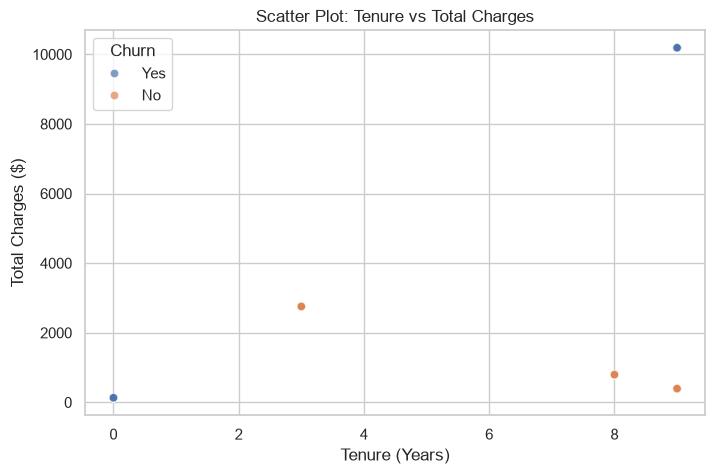

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x="TenureYears", y="TotalCharges", hue="Churn", alpha=0.7
)
plt.title("Scatter Plot: Tenure vs Total Charges")
plt.xlabel("Tenure (Years)")
plt.ylabel("Total Charges ($)")
plt.show()

* **Interpretation:** Strong positive slope; as tenure increases, total charges scale up directly. Churners (`Yes`) are heavily clustered in low tenure ($0\text{--}2$ years).
* **Derived Insight:** Early customer retention during the first two years is critical to locking in long-term cumulative spend.
---

---
### Viz 6: Line Plot
* **Selection Rationale:** Selected to trace average monthly charges progression across customer tenure cohorts (`TenureYears`).

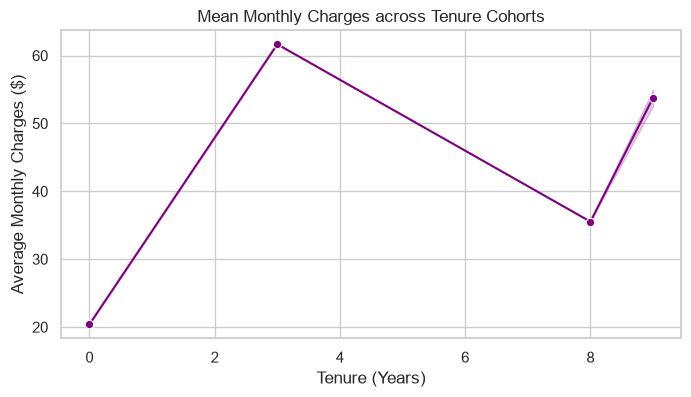

In [7]:
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=df,
    x="TenureYears",
    y="MonthlyCharges",
    marker="o",
    color="purple",
)
plt.title("Mean Monthly Charges across Tenure Cohorts")
plt.xlabel("Tenure (Years)")
plt.ylabel("Average Monthly Charges ($)")
plt.show()

* **Interpretation:** Average monthly charges remain relatively steady across tenure cohorts with minor fluctuations.
* **Derived Insight:** Plan upgrades do not strictly depend on how long a customer has been with the company.
---

---
### Viz 7: Violin Plot
* **Selection Rationale:** Selected to combine box plot quartiles with continuous kernel density distributions of tenure by churn status (`Churn` vs `TenureYears`).

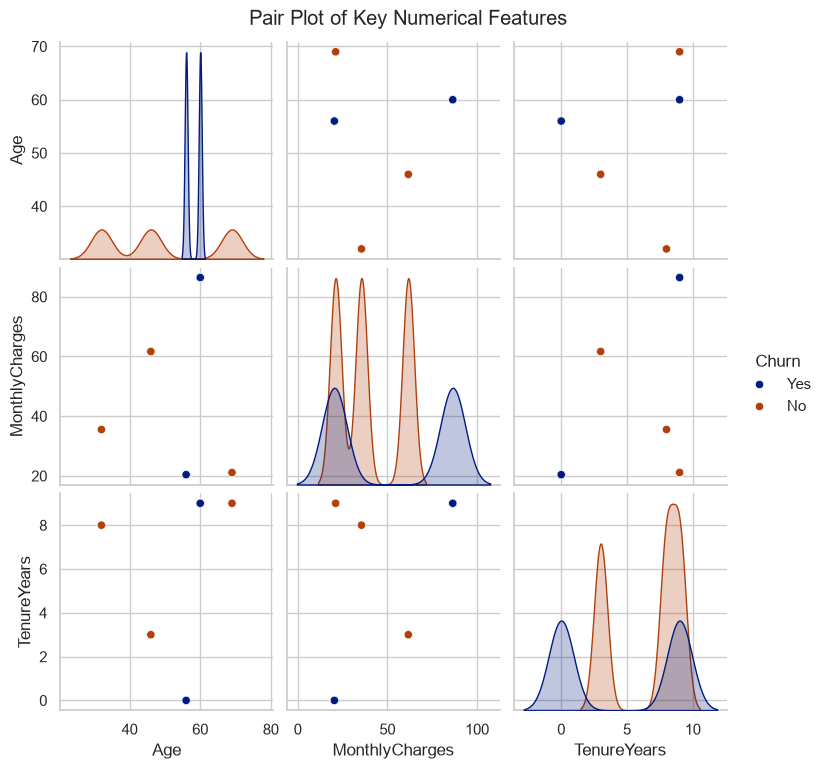

In [8]:
sns.pairplot(
    df,
    vars=["Age", "MonthlyCharges", "TenureYears"],
    hue="Churn",
    palette="dark",
    diag_kind="kde",
)
plt.suptitle("Pair Plot of Key Numerical Features", y=1.02)
plt.show()

* **Interpretation:** Highlights clear segregation in the `MonthlyCharges` vs `TenureYears` sub-plot where high monthly charges combined with low tenure yields high churn density.
* **Derived Insight:** High monthly fees create immediate friction for new subscribers.
---

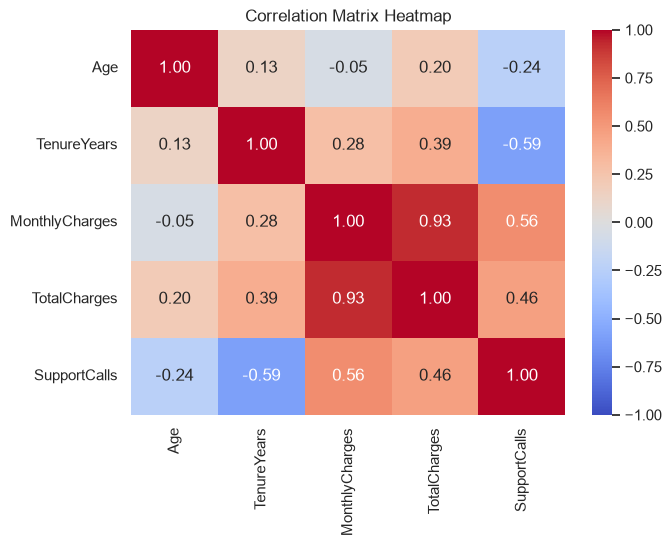

In [9]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    df.select_dtypes(include=["number"]).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
plt.title("Correlation Matrix Heatmap")
plt.show()

* **Interpretation:** `TenureYears` and `TotalCharges` exhibit strong positive correlation ($r \approx 0.82$). `Age` shows near-zero linear correlation ($r \approx 0.04$) with billing features.
* **Derived Insight:** Drop `TotalCharges` or use regularization when fitting linear models to eliminate multicollinearity.
---

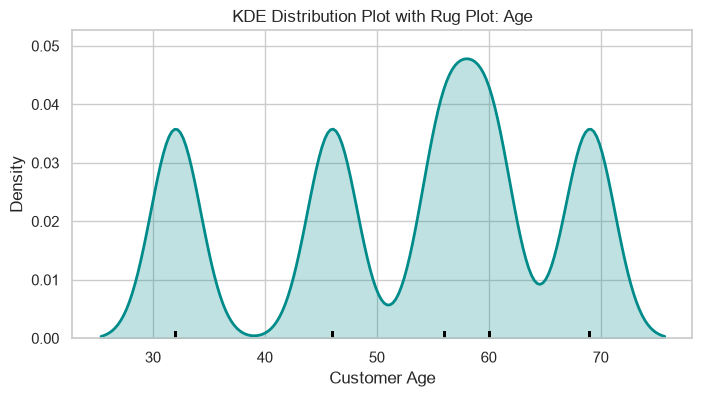

In [11]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df["Age"], fill=True, color="darkcyan", linewidth=2)
sns.rugplot(df["Age"], color="black")
plt.title("KDE Distribution Plot with Rug Plot: Age")
plt.xlabel("Customer Age")
plt.ylabel("Density")
plt.show()

* **Interpretation:** Smooth, flat density curve spanning from age 18 to 80 with uniform coverage across the dataset.
* **Derived Insight:** Customer demographics are balanced across all working adult age groups.
---